<a href="https://colab.research.google.com/github/Xtian76/TFM-ISBI/blob/main/dia_1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marwa96/isbi-ms-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'isbi-ms-dataset' dataset.
Path to dataset files: /kaggle/input/isbi-ms-dataset


In [16]:
import os

# Assuming 'path' variable from the previous step holds the dataset path
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print('{}{}/'.format(indent, os.path.basename(root)))
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print('{}{}'.format(subindent, f))

isbi-ms-dataset/
    training/
        2017-NI-Carass-Longitudinal-multiple-sclerosis-lesion-segmentation-Resource-and-challenge.pdf
        license.txt.bak
        license.txt
        training05/
            preprocessed/
                training05_02_mprage_pp.nii
                training05_03_pd_pp.nii
                training05_04_t2_pp.nii
                training05_01_t2_pp.nii
                training05_04_flair_pp.nii
                training05_03_mprage_pp.nii
                training05_03_t2_pp.nii
                training05_03_flair_pp.nii
                training05_01_pd_pp.nii
                training05_04_pd_pp.nii
                training05_02_t2_pp.nii
                training05_02_flair_pp.nii
                training05_01_mprage_pp.nii
                training05_04_mprage_pp.nii
                training05_01_flair_pp.nii
                training05_02_pd_pp.nii
            orig/
                training05_01_mprage.nii
                training05_04_t2.nii
             

In [17]:
import os

# Dictionary to store paired files
paired_files = {}

# Assuming 'path' variable from the previous step holds the dataset path
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.nii'):
            # Extract subject and scan identifier from filename
            parts = f.split('_')
            if len(parts) >= 3:
                subject_scan = '_'.join(parts[:2]) # e.g., trainingXX_YY

                if subject_scan not in paired_files:
                    paired_files[subject_scan] = {'flair_orig': None, 'flair_pp': None, 'masks': []}

                if 'flair' in f:
                    if 'preprocessed' in root:
                        paired_files[subject_scan]['flair_pp'] = os.path.join(root, f)
                    else:
                        paired_files[subject_scan]['flair_orig'] = os.path.join(root, f)
                elif 'mask' in f:
                    paired_files[subject_scan]['masks'].append(os.path.join(root, f))

# You can now access the paired files, for example:
# for subject_scan, files in paired_files.items():
#     print(f"Subject and Scan: {subject_scan}")
#     print(f"  Original FLAIR: {files.get('flair_orig')}")
#     print(f"  Preprocessed FLAIR: {files.get('flair_pp')}")
#     print(f"  Masks: {files.get('masks')}")

print(f"Created paired_files dictionary with {len(paired_files)} entries.")

Created paired_files dictionary with 21 entries.


In [18]:
# Example of loading an image and its masks using nibabel
# import nibabel as nib

# # Choose a subject and scan identifier from your paired_files dictionary
# example_subject_scan = list(paired_files.keys())[0]
# example_files = paired_files[example_subject_scan]

# # Load the preprocessed FLAIR image
# if example_files.get('flair_pp'):
#     flair_img = nib.load(example_files['flair_pp'])
#     flair_data = flair_img.get_fdata()
#     print(f"Loaded FLAIR image with shape: {flair_data.shape}")

# # Load the masks
# mask_data = []
# for mask_file in example_files.get('masks', []):
#     mask_img = nib.load(mask_file)
#     mask_data.append(mask_img.get_fdata())
#     print(f"Loaded mask with shape: {mask_img.get_fdata().shape}")

# # Now you can work with flair_data and mask_data for analysis or modeling

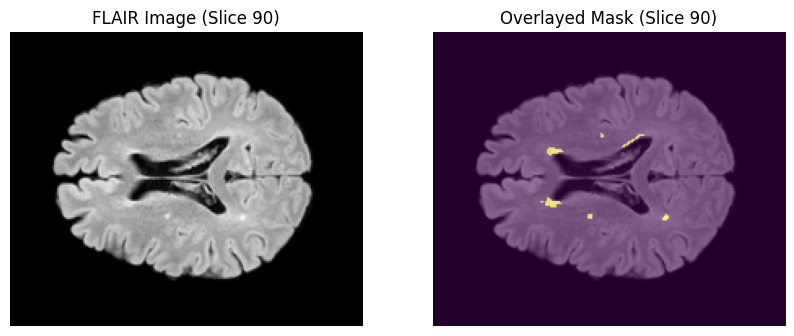

In [19]:
# Install nibabel if you haven't already
!pip install nibabel matplotlib

import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Choose a subject and scan identifier from your paired_files dictionary
# Make sure the paired_files dictionary is available from previous steps
if 'paired_files' in locals() and len(paired_files) > 0:
    example_subject_scan = list(paired_files.keys())[0]
    example_files = paired_files[example_subject_scan]

    flair_img_path = example_files.get('flair_pp') or example_files.get('flair_orig')
    mask_files_paths = example_files.get('masks', [])

    if flair_img_path:
        # Load the FLAIR image
        flair_img = nib.load(flair_img_path)
        flair_data = flair_img.get_fdata()

        # Load the masks and combine them into one mask for visualization
        combined_mask_data = None
        for mask_file in mask_files_paths:
            mask_img = nib.load(mask_file)
            mask_data = mask_img.get_fdata()
            if combined_mask_data is None:
                combined_mask_data = mask_data
            else:
                combined_mask_data = np.maximum(combined_mask_data, mask_data) # Combine masks

        # Visualize a slice
        slice_idx = flair_data.shape[2] // 2 # Choose a middle slice

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(flair_data[:, :, slice_idx], cmap='gray')
        plt.title(f'FLAIR Image (Slice {slice_idx})')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(flair_data[:, :, slice_idx], cmap='gray') # Display FLAIR as background
        if combined_mask_data is not None:
            # Overlay the mask with some transparency
            plt.imshow(combined_mask_data[:, :, slice_idx], cmap='viridis', alpha=0.5)
            plt.title(f'Overlayed Mask (Slice {slice_idx})')
        else:
             plt.title(f'No Masks Found (Slice {slice_idx})')
        plt.axis('off')

        plt.show()

    else:
        print("No FLAIR image found for the example subject and scan.")
else:
    print("paired_files dictionary not found or is empty. Please run the previous steps to create it.")

In [24]:
import nibabel as nib
import os
import SimpleITK as sitk
import numpy as np

# Assuming 'paired_files' dictionary is available from previous steps

# Create a directory to save processed images
output_dir = "/kaggle/working/processed_images"
os.makedirs(output_dir, exist_ok=True)

# Iterate through each subject and scan in the paired_files dictionary
for subject_scan, files_info in paired_files.items():
    print(f"Processing {subject_scan}...")

    flair_img_path = files_info.get('flair_pp') or files_info.get('flair_orig')
    mask_files_paths = files_info.get('masks', [])

    if flair_img_path:
        try:
            # Load the FLAIR image
            flair_img = nib.load(flair_img_path)
            flair_data = flair_img.get_fdata()
            flair_affine = flair_img.affine # Get affine transformation matrix

            print(f"  Loaded FLAIR image with shape: {flair_data.shape}")

            # Convert numpy array to SimpleITK image
            flair_sitk = sitk.GetImageFromArray(flair_data)

            # Get and set spacing
            spacing = flair_img.header.get_zooms()
            # SimpleITK expects spacing as a list or tuple of floats
            flair_sitk.SetSpacing([float(s) for s in spacing])

            # Set origin and direction
            flair_sitk.SetOrigin(flair_img.affine[:3, 3])
            # SimpleITK expects direction as a flattened list of floats
            flair_sitk.SetDirection(flair_img.affine[:3, :3].flatten().tolist())


            # Load the masks
            mask_data = []
            for mask_file in mask_files_paths:
                mask_img = nib.load(mask_file)
                mask_data.append(mask_img.get_fdata())
                print(f"  Loaded mask with shape: {mask_img.get_fdata().shape}")

            # Combine masks into a single SimpleITK mask image if multiple masks exist
            combined_mask_sitk = None
            if mask_data:
                # Assuming masks are in the same space as the flair image
                combined_mask_data = mask_data[0]
                for i in range(1, len(mask_data)):
                    combined_mask_data = np.maximum(combined_mask_data, mask_data[i])

                combined_mask_sitk = sitk.GetImageFromArray(combined_mask_data.astype(np.uint8))
                combined_mask_sitk.CopyInformation(flair_sitk) # Copy spatial information


            # Bias field correction (Step 4)
            print("  Performing bias field correction...")
            corrector = sitk.N4BiasFieldCorrectionImageFilter()
            if combined_mask_sitk:
                 corrected_sitk = corrector.Execute(flair_sitk, combined_mask_sitk)
            else:
                 corrected_sitk = corrector.Execute(flair_sitk)

            corrected_data = sitk.GetArrayFromImage(corrected_sitk)
            print("  Bias field correction finished.")

            # Intensity normalization (Step 5)
            print("  Performing intensity normalization (Z-score)...")
            # Calculate mean and standard deviation within the masked region if a mask exists
            if combined_mask_sitk:
                mask_array = sitk.GetArrayFromImage(combined_mask_sitk)
                mean_intensity = np.mean(corrected_data[mask_array > 0])
                std_intensity = np.std(corrected_data[mask_array > 0])
                # Avoid division by zero
                if std_intensity > 0:
                    normalized_data = (corrected_data - mean_intensity) / std_intensity
                else:
                    normalized_data = corrected_data - mean_intensity # Center data if std is zero
            else:
                 # Normalize the whole image if no mask is available
                mean_intensity = np.mean(corrected_data)
                std_intensity = np.std(corrected_data)
                if std_intensity > 0:
                    normalized_data = (corrected_data - mean_intensity) / std_intensity
                else:
                    normalized_data = corrected_data - mean_intensity

            print("  Intensity normalization finished.")

            # Brain extraction (Step 6)
            print("  Performing brain extraction...")
            if combined_mask_sitk:
                # Apply the combined mask to the normalized data
                brain_extracted_data = normalized_data * sitk.GetArrayFromImage(combined_mask_sitk)
                print("  Brain extraction finished.")
            else:
                brain_extracted_data = normalized_data
                print("  No mask available for brain extraction. Skipping this step.")


            # Save processed images (Step 9)
            print("  Saving processed image...")
            # Convert the processed NumPy array back to a nibabel image object
            brain_extracted_img = nib.Nifti1Image(brain_extracted_data, flair_affine)

            # Define output path
            output_filename = f"{subject_scan}_flair_processed.nii"
            output_path = os.path.join(output_dir, output_filename)

            # Save the image
            nib.save(brain_extracted_img, output_path)
            print(f"  Saved processed image to: {output_path}")


            # The next steps in the plan are:
            # 7. Co-registration (if applicable) - already discussed
            # 8. Validate preprocessing quality
            # 10. Extract basic biomarkers
            # 11. Store and analyze biomarkers

        except Exception as e:
            print(f"Error processing files for {subject_scan}: {e}")
    else:
        print(f"No FLAIR image found for {subject_scan}. Skipping.")

print("Finished loading, bias field correcting, intensity normalizing, brain extracting, and saving images for all subjects and scans.")

Processing training05_02...
  Loaded FLAIR image with shape: (181, 217, 181)
  Loaded mask with shape: (181, 217, 181)
  Loaded mask with shape: (181, 217, 181)
  Performing bias field correction...
  Bias field correction finished.
  Performing intensity normalization (Z-score)...
  Intensity normalization finished.
  Performing brain extraction...
  Brain extraction finished.
  Saving processed image...
  Saved processed image to: /kaggle/working/processed_images/training05_02_flair_processed.nii
Processing training05_03...
  Loaded FLAIR image with shape: (181, 217, 181)
  Loaded mask with shape: (181, 217, 181)
  Loaded mask with shape: (181, 217, 181)
  Performing bias field correction...
  Bias field correction finished.
  Performing intensity normalization (Z-score)...
  Intensity normalization finished.
  Performing brain extraction...
  Brain extraction finished.
  Saving processed image...
  Saved processed image to: /kaggle/working/processed_images/training05_03_flair_proces

In [21]:
# Install nibabel if you haven't already
!pip install nibabel matplotlib

In [22]:
!pip install SimpleITK

Visualizing processed image for: training05_02


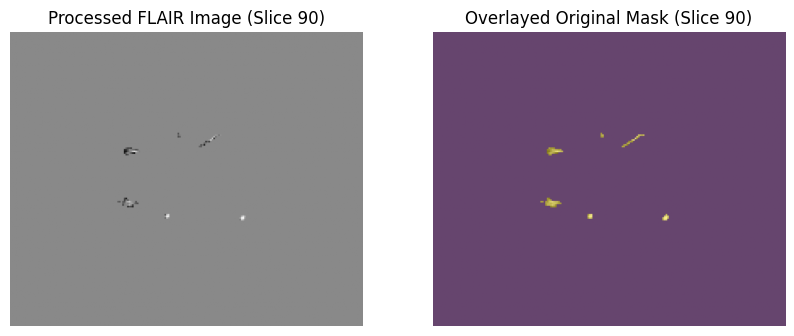

In [25]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

# Assuming 'paired_files' dictionary is available from previous steps
# Assuming processed images were saved to "/kaggle/working/processed_images"

processed_images_dir = "/kaggle/working/processed_images"

# Choose a subject and scan to visualize (you can change this index)
if 'paired_files' in locals() and len(paired_files) > 0:
    subject_scan_to_visualize = list(paired_files.keys())[0]
    print(f"Visualizing processed image for: {subject_scan_to_visualize}")

    # Construct the path to the saved processed image
    processed_img_filename = f"{subject_scan_to_visualize}_flair_processed.nii"
    processed_img_path = os.path.join(processed_images_dir, processed_img_filename)

    # Get the original mask paths for this subject and scan
    original_files_info = paired_files[subject_scan_to_visualize]
    mask_files_paths = original_files_info.get('masks', [])


    if os.path.exists(processed_img_path):
        try:
            # Load the processed FLAIR image
            processed_flair_img = nib.load(processed_img_path)
            processed_flair_data = processed_flair_img.get_fdata()

            # Load the original masks and combine them
            combined_mask_data = None
            if mask_files_paths:
                mask_data = []
                for mask_file in mask_files_paths:
                    mask_img = nib.load(mask_file)
                    mask_data.append(mask_img.get_fdata())

                combined_mask_data = mask_data[0]
                for i in range(1, len(mask_data)):
                    combined_mask_data = np.maximum(combined_mask_data, mask_data[i])


            # Visualize a slice of the processed image with the original mask overlaid
            slice_idx = processed_flair_data.shape[2] // 2 # Choose a middle slice

            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(processed_flair_data[:, :, slice_idx], cmap='gray')
            plt.title(f'Processed FLAIR Image (Slice {slice_idx})')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(processed_flair_data[:, :, slice_idx], cmap='gray') # Display processed FLAIR as background
            if combined_mask_data is not None:
                # Overlay the mask with some transparency
                plt.imshow(combined_mask_data[:, :, slice_idx], cmap='viridis', alpha=0.5)
                plt.title(f'Overlayed Original Mask (Slice {slice_idx})')
            else:
                 plt.title(f'No Original Masks Found (Slice {slice_idx})')
            plt.axis('off')

            plt.show()

        except Exception as e:
            print(f"Error visualizing processed image for {subject_scan_to_visualize}: {e}")
    else:
        print(f"Processed image not found for {subject_scan_to_visualize} at {processed_img_path}")

else:
    print("paired_files dictionary not found or is empty. Cannot visualize processed images.")

In [26]:
import nibabel as nib
import numpy as np
import os
import pandas as pd

# Assuming 'paired_files' dictionary is available from previous steps
# Assuming processed images were saved to "/kaggle/working/processed_images"

processed_images_dir = "/kaggle/working/processed_images"

# List to store biomarker data for each subject/scan
biomarker_data = []

if 'paired_files' in locals() and len(paired_files) > 0:
    print("Extracting biomarkers...")
    for subject_scan, files_info in paired_files.items():
        processed_img_filename = f"{subject_scan}_flair_processed.nii"
        processed_img_path = os.path.join(processed_images_dir, processed_img_filename)

        # Get the original mask paths for this subject and scan
        original_files_info = paired_files[subject_scan]
        mask_files_paths = original_files_info.get('masks', [])

        if os.path.exists(processed_img_path) and mask_files_paths:
            try:
                # Load the processed FLAIR image and combined mask
                processed_flair_img = nib.load(processed_img_path)
                processed_flair_data = processed_flair_img.get_fdata()
                voxel_size = processed_flair_img.header.get_zooms() # Get voxel dimensions

                combined_mask_data = None
                if mask_files_paths:
                    mask_data = []
                    for mask_file in mask_files_paths:
                        mask_img = nib.load(mask_file)
                        mask_data.append(mask_img.get_fdata())

                    combined_mask_data = mask_data[0]
                    for i in range(1, len(mask_data)):
                        combined_mask_data = np.maximum(combined_mask_data, mask_data[i])

                if combined_mask_data is not None:
                    # Ensure mask data is binary (0 or 1)
                    binary_mask = (combined_mask_data > 0).astype(np.uint8)

                    # Calculate Total Lesion Volume (Step 10a)
                    # Count the number of non-zero voxels in the binary mask
                    num_lesion_voxels = np.sum(binary_mask)
                    # Calculate voxel volume in cubic mm (assuming voxel_size is in mm)
                    voxel_volume_mm3 = voxel_size[0] * voxel_size[1] * voxel_size[2]
                    total_lesion_volume_mm3 = num_lesion_voxels * voxel_volume_mm3

                    # Calculate Number of Lesions (Step 10b)
                    # This is more complex and typically requires connected components analysis.
                    # For simplicity and as a basic biomarker, we can report the total number of masks if multiple are provided,
                    # or note that advanced lesion counting requires further steps.
                    num_lesions = len(mask_files_paths) # Simple count of provided mask files

                    # Extract Intensity Statistics within Lesions (Step 10d)
                    # Get intensity values from the processed image where the mask is > 0
                    lesion_intensities = processed_flair_data[binary_mask > 0]
                    mean_lesion_intensity = np.mean(lesion_intensities) if lesion_intensities.size > 0 else 0
                    std_lesion_intensity = np.std(lesion_intensities) if lesion_intensities.size > 0 else 0
                    median_lesion_intensity = np.median(lesion_intensities) if lesion_intensities.size > 0 else 0

                    # Store the extracted biomarkers
                    biomarker_data.append({
                        'Subject_Scan': subject_scan,
                        'Total_Lesion_Volume_mm3': total_lesion_volume_mm3,
                        'Number_of_Mask_Files': num_lesions, # Simple count of mask files
                        'Mean_Lesion_Intensity': mean_lesion_intensity,
                        'Std_Lesion_Intensity': std_lesion_intensity,
                        'Median_Lesion_Intensity': median_lesion_intensity
                        # Spatial distribution (Step 10c) would require more advanced analysis
                    })
                else:
                    print(f"  No masks found for {subject_scan}. Cannot extract lesion biomarkers.")

            except Exception as e:
                print(f"Error extracting biomarkers for {subject_scan}: {e}")
        else:
            print(f"Processed image or masks not found for {subject_scan}. Skipping biomarker extraction.")

    # Convert the list of dictionaries to a pandas DataFrame (Step 11)
    biomarkers_df = pd.DataFrame(biomarker_data)

    # Display the DataFrame
    print("\nBiomarkers Extracted:")
    display(biomarkers_df)

else:
    print("paired_files dictionary not found or is empty. Cannot extract biomarkers.")

print("\nFinished biomarker extraction.")

Extracting biomarkers...

Biomarkers Extracted:


,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity
0,training05_02,6031.0,2,9.896467e-17,1.0,-0.104850
1,training05_03,5535.0,2,-1.191298e-15,1.0,0.006044
2,training05_04,5455.0,2,-3.165204e-16,1.0,-0.059039
3,training05_01,5895.0,2,-1.460861e-15,1.0,-0.074636
4,training04_03,3856.0,2,7.370775e-17,1.0,0.049150
5,training04_02,3626.0,2,-2.860983e-15,1.0,0.036744
6,training04_04,3555.0,2,1.151259e-15,1.0,0.071895
7,training04_01,4008.0,2,7.977650e-16,1.0,-0.107932
8,training03_01,10917.0,2,-5.727559e-17,1.0,-0.214007
9,training03_05,7756.0,2,-1.099344e-16,1.0,-0.074831



Finished biomarker extraction.


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Total_Lesion_Volume_mm3'].plot(kind='hist', bins=20, title='Total_Lesion_Volume_mm3')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['Median_Lesion_Intensity']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('Median_Lesion_Intensity')

from matplotlib import pyplot as plt
_df_12['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['Total_Lesion_Volume_mm3'].plot(kind='line', figsize=(8, 4), title='Total_Lesion_Volume_mm3')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Mean_Lesion_Intensity'].plot(kind='line', figsize=(8, 4), title='Mean_Lesion_Intensity')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['Std_Lesion_Intensity'].plot(kind='line', figsize=(8, 4), title='Std_Lesion_Intensity')
plt.gca().spines[['top', 'right']].set_visible(False)

In [27]:
# Summarize the DataFrame
print("DataFrame Info:")
biomarkers_df.info()

print("\nDataFrame Description:")
display(biomarkers_df.describe())

print("\nFirst 5 rows of the DataFrame:")
display(biomarkers_df.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Subject_Scan             21 non-null     object 
 1   Total_Lesion_Volume_mm3  21 non-null     float64
 2   Number_of_Mask_Files     21 non-null     int64  
 3   Mean_Lesion_Intensity    21 non-null     float64
 4   Std_Lesion_Intensity     21 non-null     float64
 5   Median_Lesion_Intensity  21 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.1+ KB

DataFrame Description:


,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity
count,21.000000,21.0,2.100000e+01,2.100000e+01,21.000000
mean,14752.285714,2.0,-2.967337e-16,1.000000e+00,-0.049233
std,12364.285714,0.0,1.237806e-15,9.614813e-17,0.062852
min,3555.000000,2.0,-2.905430e-15,1.000000e+00,-0.214007
25%,5535.000000,2.0,-1.191298e-15,1.000000e+00,-0.080192
50%,7756.000000,2.0,-1.099344e-16,1.000000e+00,-0.059039
75%,21353.000000,2.0,7.977650e-16,1.000000e+00,-0.018233
max,38607.000000,2.0,1.759847e-15,1.000000e+00,0.071895



First 5 rows of the DataFrame:


,Subject_Scan,Total_Lesion_Volume_mm3,Number_of_Mask_Files,Mean_Lesion_Intensity,Std_Lesion_Intensity,Median_Lesion_Intensity
0,training05_02,6031.0,2,9.896467e-17,1.0,-0.104850
1,training05_03,5535.0,2,-1.191298e-15,1.0,0.006044
2,training05_04,5455.0,2,-3.165204e-16,1.0,-0.059039
3,training05_01,5895.0,2,-1.460861e-15,1.0,-0.074636
4,training04_03,3856.0,2,7.370775e-17,1.0,0.049150
